In [ ]:
# instalação de dependências
# !pip install deepface==0.0.91 tensorflow==2.9.3 keras==2.9.0 numpy==1.26.4 opencv-python matplotlib protobuf>=4.25.1 
# !pip install albucore>=0.0.24 albumentations>=2.0.8 onnx>=1.18.0 opencv-python-headless
# versão do Python 3.9.23

import cv2

import matplotlib.pyplot as plt
import numpy as np
import os
import subprocess
import sys

from deepface import DeepFace # biblioteca de análise de emoções 

# detecção de emoções:
#  Modelo	     Tipo	           Descrição
# VGG-Face	    CNN	              Modelo padrão do DeepFace. Bom equilíbrio entre precisão e velocidade.
# Facenet	    Embedding	      Muito preciso, ideal para aplicações sensíveis.
# Facenet512	Embedding	      Versão maior do Facenet, com vetores de 512 dimensões. Mais lento, mas mais preciso.
# OpenFace	    Embedding	      Leve e rápido. Vetores de 128 dimensões. Útil para aplicações em tempo real.

# detecção de rostos:
#  Detector	     Descrição
# opencv	    Rápido, mas menos preciso. Funciona offline.
# ssd	        Detector com base em Single Shot MultiBox. Mais preciso.
# dlib	        Detecção via HOG ou CNN. Leve, mas pode falhar em ângulos extremos.
# mtcnn	        Muito preciso, mas pesado.
# retinaface	Padrão atual. Usa medições com landmarks. Ótimo para tarefas demográficas.
# mediapipe	    Modelo do Google. Rápido, eficiente e funciona bem em vídeos.

# modelos usados para detecção demografica:
#  Submódulos e funções:
#  Ação (actions)	 Modelos usados (internamente)	 Função
# 'emotion'	        Emotion	                        Classifica emoções (feliz, triste, raiva, etc.)
# 'age'	            Age	                            Estima idade (regressão)
# 'gender'	        Gender	                        Classifica como "Man" ou "Woman"
# 'race'	        Race	                        Classifica entre raças (White, Black, Asian etc.)

try:
    import insightface # biblioteca de geração de embeddings faciais
except ModuleNotFoundError:
    print("Biblioteca 'insightface' não encontrada. Tentando instalar automaticamente...\n")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "insightface[all]", "onnxruntime", "onnxruntime-gpu"])
        import insightface
        print("\n✅ Instalação concluída com sucesso!")
    except subprocess.CalledProcessError as e:
        error_msg = str(e)
        
        # Caso de erro de permissão (WinError 5)
        if "WinError 5" in error_msg:
            print("\n❌ Erro de permissão detectado (WinError 5).")
            print("Feche todos os programas que estejam usando Python (incluindo Jupyter).")
            print("Tente novamente executando este script como Administrador.\n")
        
        # Caso de falta de compilador
        elif "Microsoft Visual C++" in error_msg or "cl.exe" in error_msg:
            print("\n❌ Parece que você não tem o Microsoft C++ Build Tools instalado.")
            print("Baixe e instale em: https://visualstudio.microsoft.com/visual-cpp-build-tools/")
            print("Durante a instalação, selecione o pacote 'Desenvolvimento para desktop com C++'.\n")
        
        else:
            print("\n❌ Ocorreu um erro ao instalar o insightface:")
            print(error_msg)

!pip install onnxruntime onnxruntime-gpu
from insightface.app import FaceAnalysis
from scipy.spatial.distance import cosine

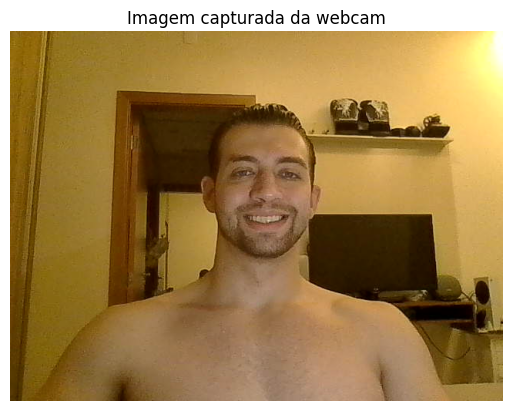

In [3]:
# captura de imagem local

# Abre a webcam (0 = webcam padrão)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Erro ao abrir a webcam")
else:
    # Captura um frame
    ret, frame = cap.read()

    if ret:
        # Libera a webcam imediatamente (evita travar a câmera em Jupyter)
        cap.release()

        # Converte BGR para RGB (OpenCV usa BGR, Matplotlib espera RGB)
        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Exibe a imagem no notebook
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title("Imagem capturada da webcam")
        plt.show()
    else:
        print("Falha ao capturar imagem")
        cap.release()

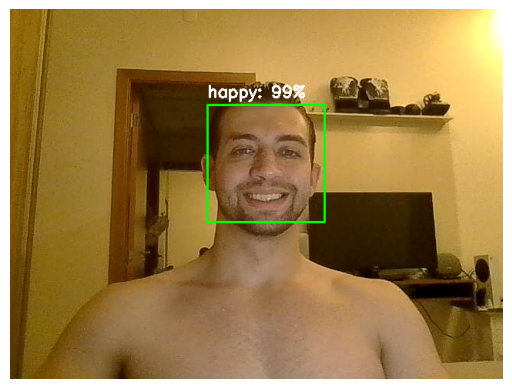

In [4]:
# Lê e converte a imagem
img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

try:
    # Análise de emoção
    results = DeepFace.analyze(img_rgb, actions=['emotion'], enforce_detection=False)

    # Garante que seja uma lista (caso só haja uma face)
    if not isinstance(results, list):
        results = [results]

    for res in results:
        region = res['region']
        x, y, w, h = region['x'], region['y'], region['w'], region['h']
        emotion = res['dominant_emotion']
        confidence = int(res['emotion'][emotion])
        texto = f"{emotion}: {confidence}%"

        # Retângulo no rosto
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Posição do texto
        (text_w, text_h), baseline = cv2.getTextSize(texto, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        text_y = y - 10 if y - text_h - baseline > 0 else y + h + text_h + 10

        # # Fundo do texto
        # cv2.rectangle(img_rgb,
        #               (x, text_y - text_h - baseline),
        #               (x + text_w, text_y + baseline),
        #               (0, 0, 0),
        #               thickness=cv2.FILLED)

        # Texto da emoção
        cv2.putText(img_rgb, texto, (x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

except Exception as e:
    if (e == "Erro na análise: module 'deepface.modules.modeling' has no attribute 'build_model'"):
            print("Erro de compatibilidade de versão dos pacotes")
        print(f"Erro na análise: {e}")

# Exibe imagem anotada
plt.imshow(img_rgb)
plt.axis('off')
# plt.title("Imagem anotada")
plt.show()

In [ ]:
# Análise de frames em tempo real por captura de video
# Inicia a captura de vídeo
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    try:
        # Analisa o frame atual
        result = DeepFace.analyze(
            frame,
            actions=['age', 'gender', 'emotion'],
            enforce_detection=True,
            detector_backend='opencv'
        )

        # Garantir compatibilidade com múltiplas detecções
        if isinstance(result, list):
            result = result[0]

        # Coordenadas do rosto detectado
        x, y, w, h = result['region']['x'], result['region']['y'], result['region']['w'], result['region']['h']

        # Desenha retângulo no rosto
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Extrai informações
        gender = result['dominant_gender']
        # gender_conf = result['gender'][gender]
        age = result['age']
        emotion = result['dominant_emotion']
        emotion_conf = result['emotion'][emotion]

        # Texto a ser exibido
        lines = [
            f"{gender}",
            f"{age} anos", # idade é uma predição direta, sem probabilidade
            f"{emotion} - {emotion_conf:.0f}%"
        ]

        # Exibe texto acima do retângulo
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        thickness = 1
        text_color = (255, 255, 255)
        bg_color = (0, 0, 0)

        for i, line in enumerate(lines):
            (tw, th), _ = cv2.getTextSize(line, font, font_scale, thickness)
            tx, ty = x, y - 10 - (len(lines) - i - 1) * (th + 5)
            cv2.rectangle(frame, (tx, ty - th), (tx + tw, ty + 5), bg_color, -1)
            cv2.putText(frame, line, (tx, ty), font, font_scale, text_color, thickness, cv2.LINE_AA)

    except Exception as e:
        if (e == "Erro na análise: module 'deepface.modules.modeling' has no attribute 'build_model'"):
            print("Erro de compatibilidade de versão dos pacotes")
        print("Erro:", e)

    cv2.imshow("Rosto Detectado", frame)

    # Pressione 'q' para sair
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


In [ ]:
#análise de frames - capacidade para detecção de multiplos rostos

# Inicializa a webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    try:
        # Realiza análise dos rostos (sem forçar detecção)
        results = DeepFace.analyze(frame, actions=['age', 'gender', 'emotion'], enforce_detection=False)

        # Garante que results seja uma lista
        if isinstance(results, dict):
            results = [results]

        for result in results:
            region = result['region']
            x, y, w, h = region['x'], region['y'], region['w'], region['h']

            # Desenha retângulo ao redor do rosto
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

            # Extrai os dados disponíveis
            gender_dict = result.get('gender', 'N/A')
            gender = max(gender_dict, key=gender_dict.get)
            age = result.get('age', 'N/A')
            dominant_emotion = result.get('dominant_emotion', 'N/A')
            emotion_confidence = result.get('emotion', {}).get(dominant_emotion, 0)

            # Monta o texto para exibir
            text_lines = [
                f"{dominant_emotion} - {emotion_confidence:.0f}%",
                f"{age} anos",
                f"{gender}"
            ]

            # Exibe o texto linha por linha acima do rosto
            for i, line in enumerate(text_lines):
                y_pos = max(y - 10 - i*20, 0)  # Evita texto fora da imagem
                cv2.putText(
                    frame,
                    line,
                    (x, y_pos),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 255, 255), # os dados serão impressos na cor branca
                    1,
                    cv2.LINE_AA
                )

    except Exception as e:
        print("Erro:", e)

    # Exibe o resultado
    cv2.imshow('Rostos detectados', frame)

    # Pressione 'q' para sair
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


In [1]:
# testando quais mecanismos de execução estão disponiveis
import onnxruntime as ort
from insightface.app import FaceAnalysis

if 'CUDAExecutionProvider' in ort.get_all_providers():
    providers = ['CUDAExecutionProvider']
    print("Usando GPU com CUDA.")
else:
    providers = ['CPUExecutionProvider']
    print("Usando CPU.")

face_app = FaceAnalysis(name='buffalo_l', providers=providers)
face_app.prepare(ctx_id=0)

# Exemplo de saída esperada: ['CPUExecutionProvider', 'CUDAExecutionProvider', ...]

ModuleNotFoundError: No module named 'onnxruntime'

In [ ]:
# modelo de geração e comparação de embeddings de rostos para identificação de rosto
import cv2
import insightface
import numpy as np
from insightface.app import FaceAnalysis
from scipy.spatial.distance import cosine

# supõe a existencia de um banco de dados de embeddings de usuarios:
# Simula banco de embeddings cadastrados
# Esses embeddings devem ser extraídos previamente e salvos
# Exemplo: {'Rafael': embedding_vector, ...}
user_database = {}

# Inicializa o modelo (ArcFace com detecção e extração de embeddings)
face_app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider']) # CPUExecutionProvider = cpu // CUDAExecutionProvider = gpu
face_app.prepare(ctx_id=0)

# Função para calcular similaridade
def identify_user(face_embedding, database, threshold=0.5):
    best_match = None
    lowest_distance = float('inf')

    for name, stored_embedding in database.items():
        distance = cosine(face_embedding, stored_embedding)
        if distance < lowest_distance:
            best_match = name
            lowest_distance = distance

    if lowest_distance < threshold:
        return best_match
    else:
        return "Desconhecido"

# Inicializa webcam
cap = cv2.VideoCapture(0)

print("Pressione 'c' para cadastrar rosto, 'q' para sair.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    faces = face_app.get(frame)

    for face in faces:
        box = face.bbox.astype(int)
        embedding = face.embedding

        # Identifica usuário
        user = identify_user(embedding, user_database)

        # Exibe nome do usuário identificado
        cv2.rectangle(frame, tuple(box[:2]), tuple(box[2:]), (0, 255, 0), 2)
        cv2.putText(frame, user, (box[0], box[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    cv2.imshow("Reconhecimento Facial", frame)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('q'):
        break

    # Cadastro de novo usuário
    elif key == ord('c') and faces:
        nome = input("Nome do usuário: ")
        user_database[nome] = faces[0].embedding
        print(f"Usuário '{nome}' cadastrado.")

cap.release()
cv2.destroyAllWindows()